In [407]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [408]:
df = pd.read_csv("dataset/water_potability.csv")

In [409]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [410]:
df.shape

(3276, 10)

In [411]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [412]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [413]:
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

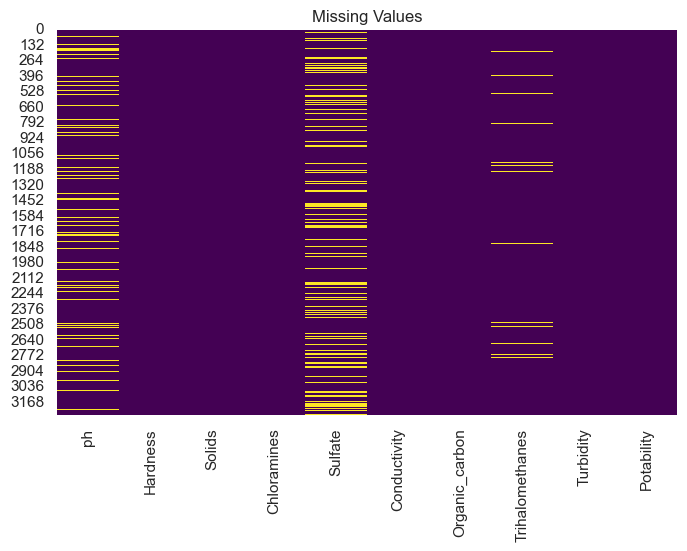

In [414]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values")
plt.savefig("images/missing_values.png", dpi=300, bbox_inches="tight")
plt.show()

In [415]:
imputer = SimpleImputer(strategy="median")

df = pd.DataFrame(
    imputer.fit_transform(df),
    columns=df.columns
)

In [416]:
df.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

In [417]:
df.duplicated().sum()

np.int64(0)

In [418]:
df = df.drop_duplicates()

In [419]:
df["Potability"].value_counts()

Potability
0.0    1998
1.0    1278
Name: count, dtype: int64

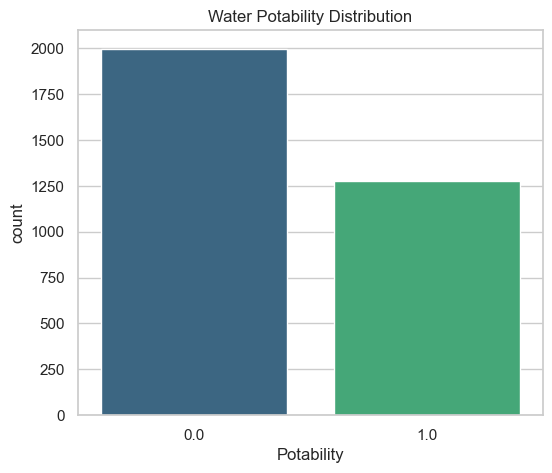

In [420]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="Potability",
    data=df,
    palette="viridis"
)

plt.title("Water Potability Distribution")
plt.show()

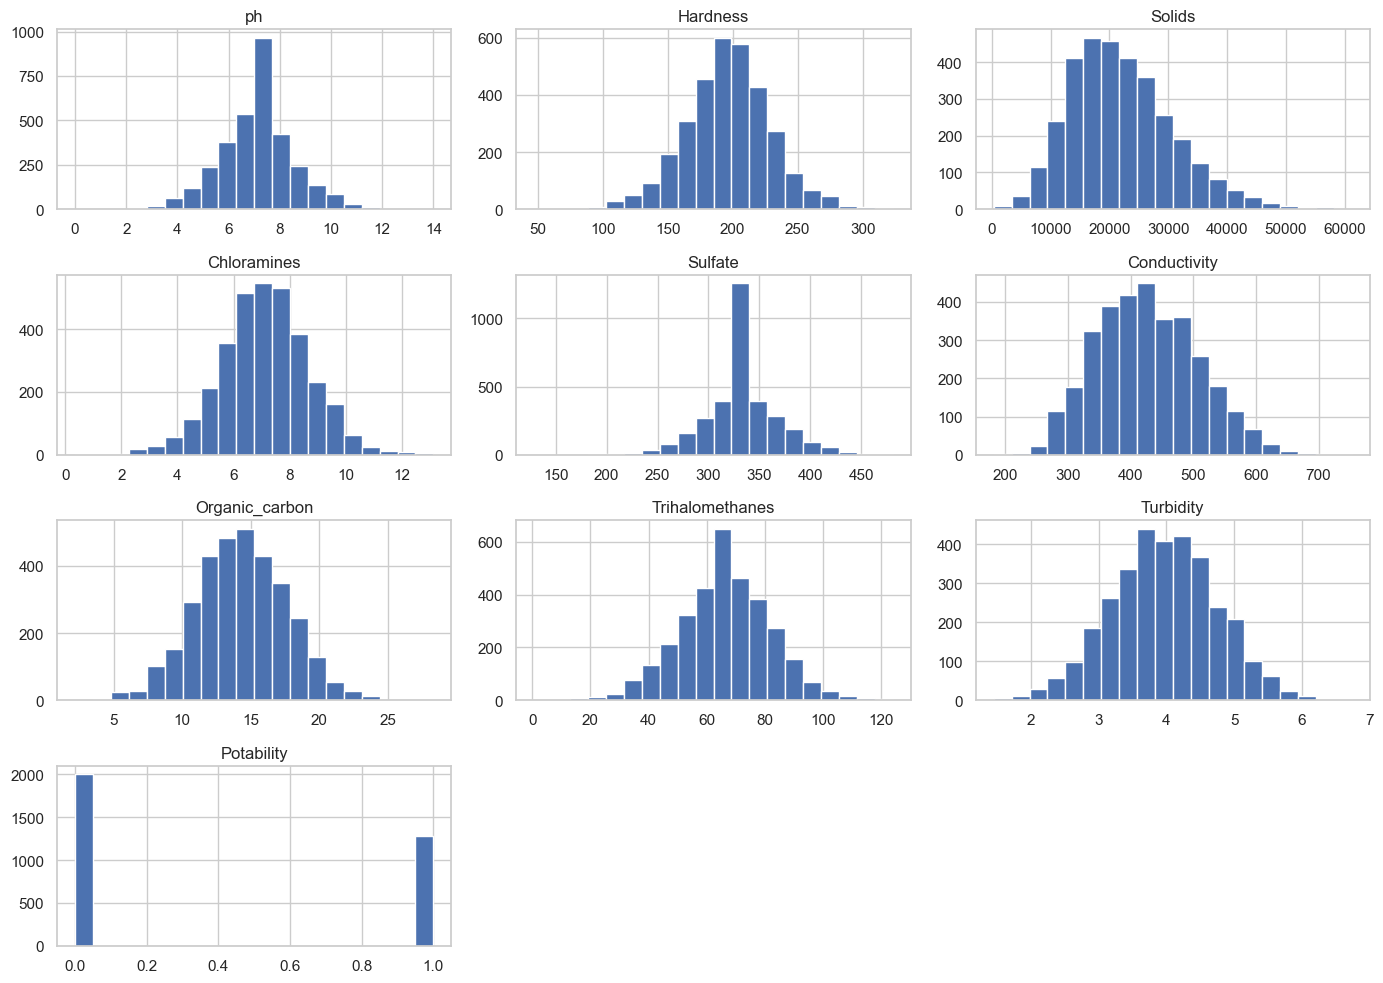

In [421]:
df.hist(figsize=(14,10), bins=20)

plt.tight_layout()
plt.show()

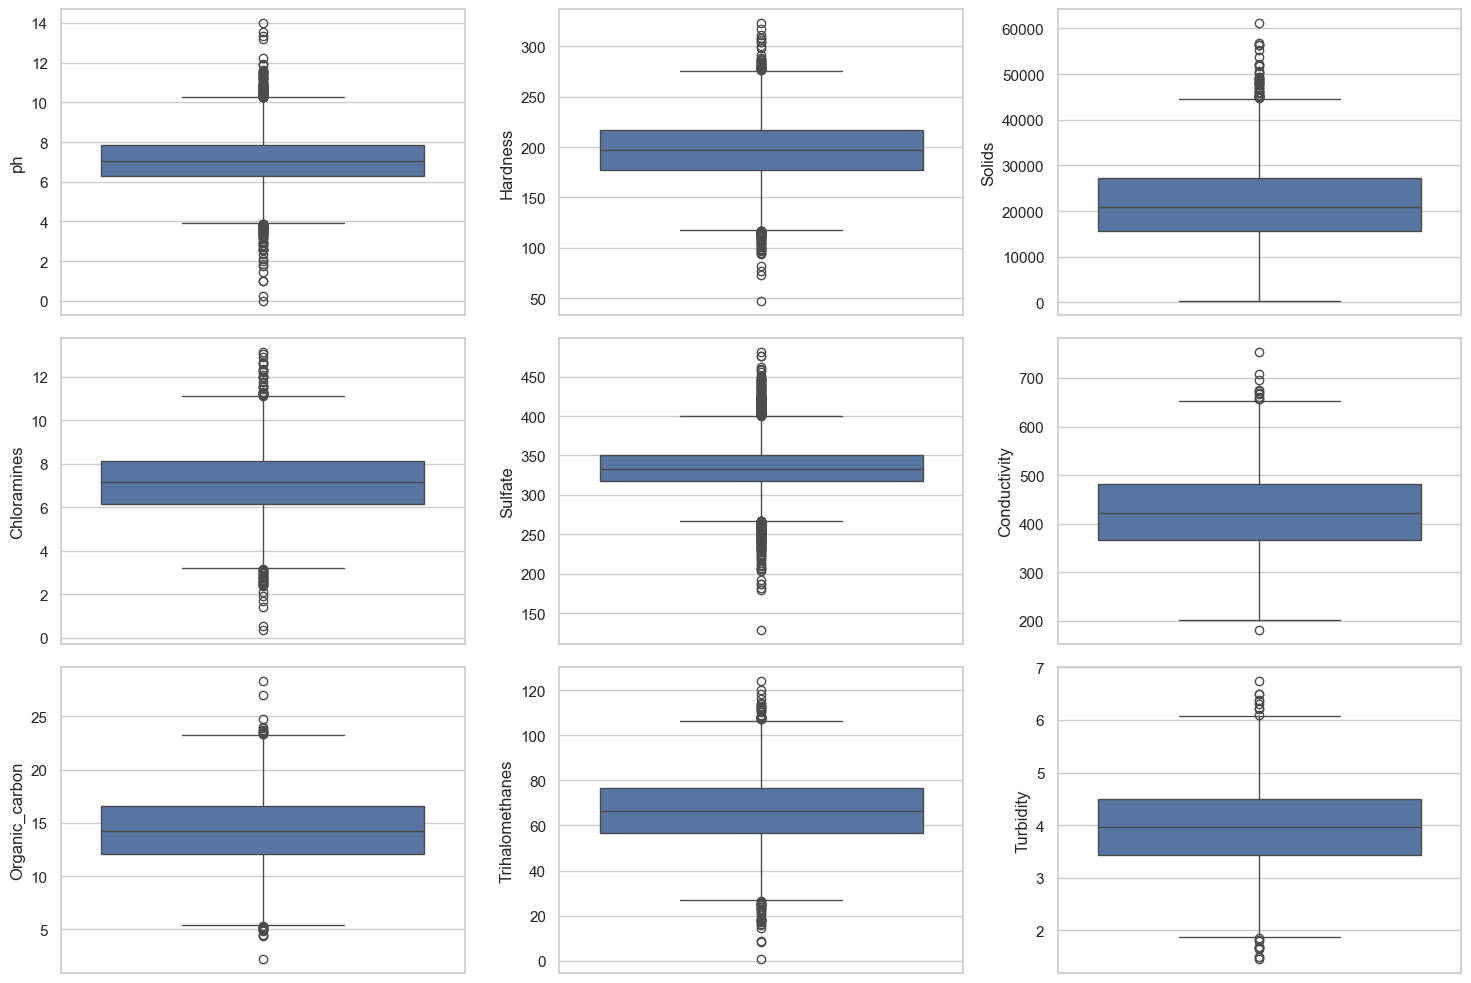

In [422]:
plt.figure(figsize=(15,10))

for i, col in enumerate(df.columns[:-1]):
    plt.subplot(3,3,i+1)
    sns.boxplot(y=df[col])

plt.tight_layout()
plt.show()

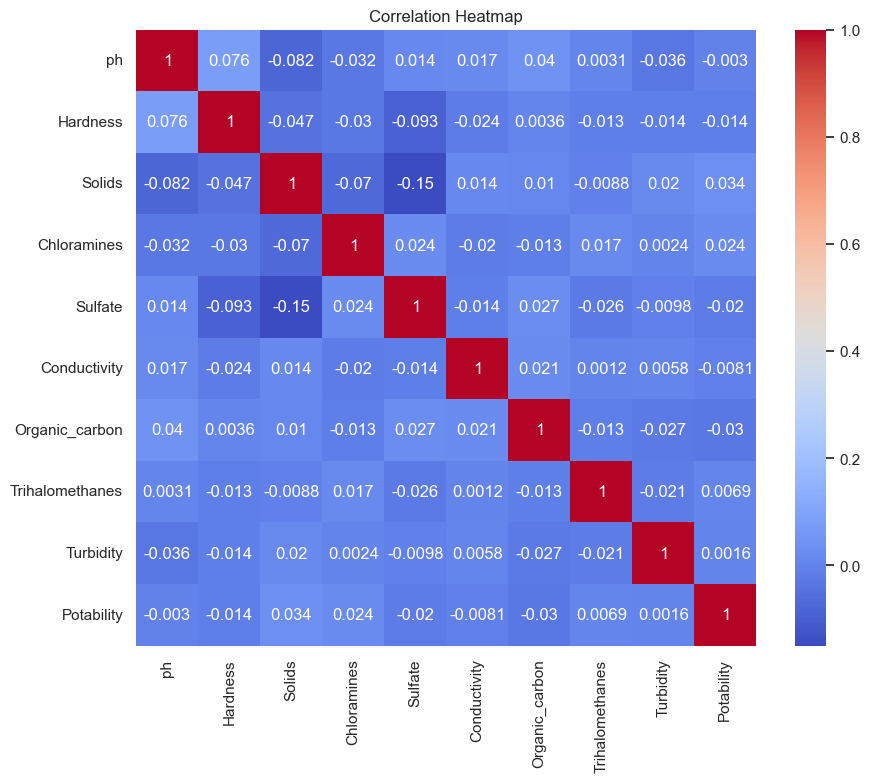

In [423]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [424]:
X = df.drop("Potability", axis=1)

y = df["Potability"]

In [425]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [426]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X, y = smote.fit_resample(X, y)

print("After SMOTE:")
print(pd.Series(y).value_counts())

After SMOTE:
Potability
0.0    1998
1.0    1998
Name: count, dtype: int64


In [427]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [428]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3196, 9)
(800, 9)
(3196,)
(800,)


In [429]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

In [430]:
dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=10,
)

dt.fit(X_train,y_train)

pred_dt = dt.predict(X_test)

In [431]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    random_state=42,
)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

In [432]:
knn = KNeighborsClassifier(
    n_neighbors=7
)
knn.fit(X_train,y_train)

pred_knn = knn.predict(X_test)

In [433]:
svm = SVC(
    kernel="rbf",
    C=5,
    gamma="scale",
    probability=True,
    random_state=42
)

svm.fit(X_train,y_train)

pred_svm = svm.predict(X_test)

In [434]:
def evaluate_model(name, y_true, y_pred, y_prob):

    print("="*60)
    print(name)
    print("="*60)

    print("Accuracy :", accuracy_score(y_true,y_pred))
    print("Precision:", precision_score(y_true,y_pred))
    print("Recall   :", recall_score(y_true,y_pred))
    print("F1 Score :", f1_score(y_true,y_pred))
    print("ROC AUC  :", roc_auc_score(y_true,y_prob))

    print("\nClassification Report\n")
    print(classification_report(y_true,y_pred))

    plt.figure(figsize=(5,4))

    sns.heatmap(
        confusion_matrix(y_true,y_pred),
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

Logistic Regression
Accuracy : 0.515
Precision: 0.515
Recall   : 0.515
F1 Score : 0.515
ROC AUC  : 0.53393125

Classification Report

              precision    recall  f1-score   support

         0.0       0.52      0.52      0.52       400
         1.0       0.52      0.52      0.52       400

    accuracy                           0.52       800
   macro avg       0.52      0.52      0.52       800
weighted avg       0.52      0.52      0.52       800



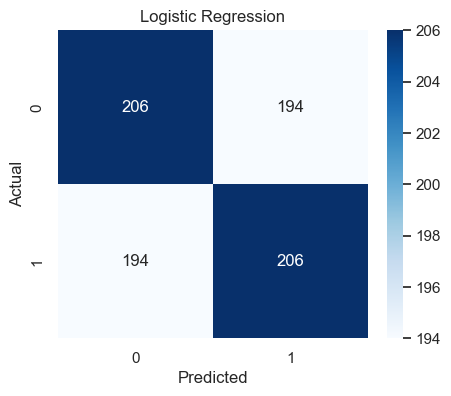

In [435]:
evaluate_model(
    "Logistic Regression",
    y_test,
    pred_lr,
    lr.predict_proba(X_test)[:,1]
)

Decision Tree
Accuracy : 0.6125
Precision: 0.6097560975609756
Recall   : 0.625
F1 Score : 0.6172839506172839
ROC AUC  : 0.652709375

Classification Report

              precision    recall  f1-score   support

         0.0       0.62      0.60      0.61       400
         1.0       0.61      0.62      0.62       400

    accuracy                           0.61       800
   macro avg       0.61      0.61      0.61       800
weighted avg       0.61      0.61      0.61       800



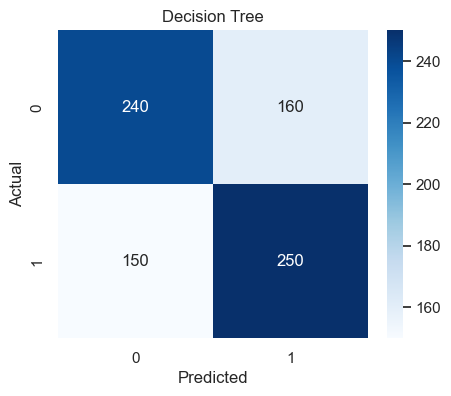

In [436]:
evaluate_model(
    "Decision Tree",
    y_test,
    pred_dt,
    dt.predict_proba(X_test)[:,1]
)

Random Forest
Accuracy : 0.73625
Precision: 0.7454545454545455
Recall   : 0.7175
F1 Score : 0.7312101910828025
ROC AUC  : 0.7999062499999999

Classification Report

              precision    recall  f1-score   support

         0.0       0.73      0.76      0.74       400
         1.0       0.75      0.72      0.73       400

    accuracy                           0.74       800
   macro avg       0.74      0.74      0.74       800
weighted avg       0.74      0.74      0.74       800



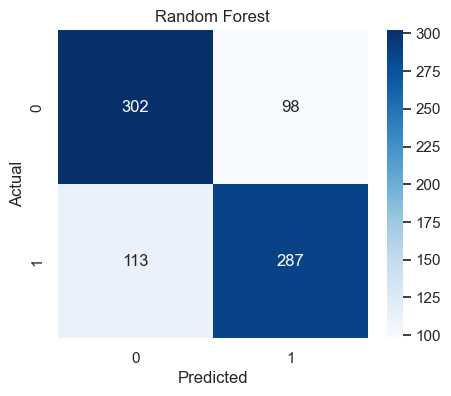

In [437]:
evaluate_model(
    "Random Forest",
    y_test,
    pred_rf,
    rf.predict_proba(X_test)[:,1]
)

KNN
Accuracy : 0.65125
Precision: 0.6479217603911981
Recall   : 0.6625
F1 Score : 0.6551297898640297
ROC AUC  : 0.702478125

Classification Report

              precision    recall  f1-score   support

         0.0       0.65      0.64      0.65       400
         1.0       0.65      0.66      0.66       400

    accuracy                           0.65       800
   macro avg       0.65      0.65      0.65       800
weighted avg       0.65      0.65      0.65       800



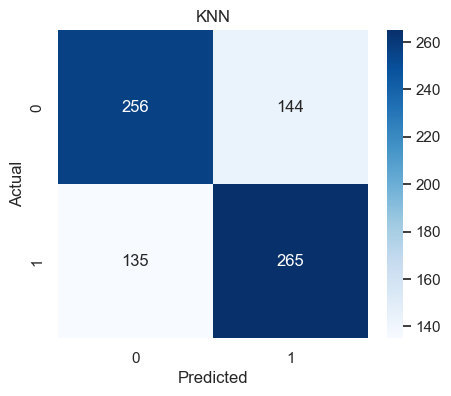

In [438]:
evaluate_model(
    "KNN",
    y_test,
    pred_knn,
    knn.predict_proba(X_test)[:,1]
)

SVM
Accuracy : 0.6475
Precision: 0.6467661691542289
Recall   : 0.65
F1 Score : 0.6483790523690773
ROC AUC  : 0.72454375

Classification Report

              precision    recall  f1-score   support

         0.0       0.65      0.65      0.65       400
         1.0       0.65      0.65      0.65       400

    accuracy                           0.65       800
   macro avg       0.65      0.65      0.65       800
weighted avg       0.65      0.65      0.65       800



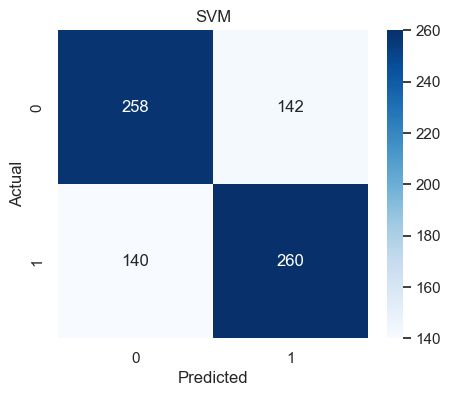

In [439]:
evaluate_model(
    "SVM",
    y_test,
    pred_svm,
    svm.predict_proba(X_test)[:,1]
)

In [440]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVM"
    ],

    "Accuracy":[
        accuracy_score(y_test,pred_lr),
        accuracy_score(y_test,pred_dt),
        accuracy_score(y_test,pred_rf),
        accuracy_score(y_test,pred_knn),
        accuracy_score(y_test,pred_svm)
    ],

    "Precision":[
        precision_score(y_test,pred_lr),
        precision_score(y_test,pred_dt),
        precision_score(y_test,pred_rf),
        precision_score(y_test,pred_knn),
        precision_score(y_test,pred_svm)
    ],

    "Recall":[
        recall_score(y_test,pred_lr),
        recall_score(y_test,pred_dt),
        recall_score(y_test,pred_rf),
        recall_score(y_test,pred_knn),
        recall_score(y_test,pred_svm)
    ],

    "F1 Score":[
        f1_score(y_test,pred_lr),
        f1_score(y_test,pred_dt),
        f1_score(y_test,pred_rf),
        f1_score(y_test,pred_knn),
        f1_score(y_test,pred_svm)
    ]
})

results.sort_values("Accuracy",ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.73625,0.745455,0.7175,0.731210
3,KNN,0.65125,0.647922,0.6625,0.655130
4,SVM,0.64750,0.646766,0.6500,0.648379
1,Decision Tree,0.61250,0.609756,0.6250,0.617284
0,Logistic Regression,0.51500,0.515000,0.5150,0.515000


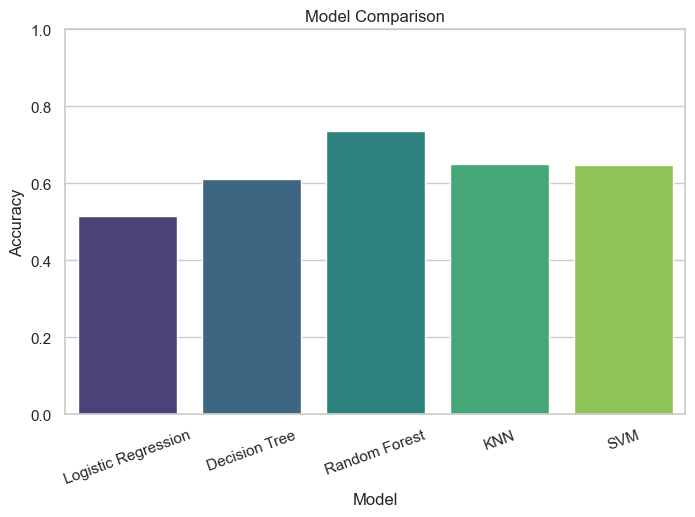

In [441]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy",
    palette="viridis"
)

plt.xticks(rotation=20)

plt.ylim(0,1)

plt.title("Model Comparison")

plt.show()

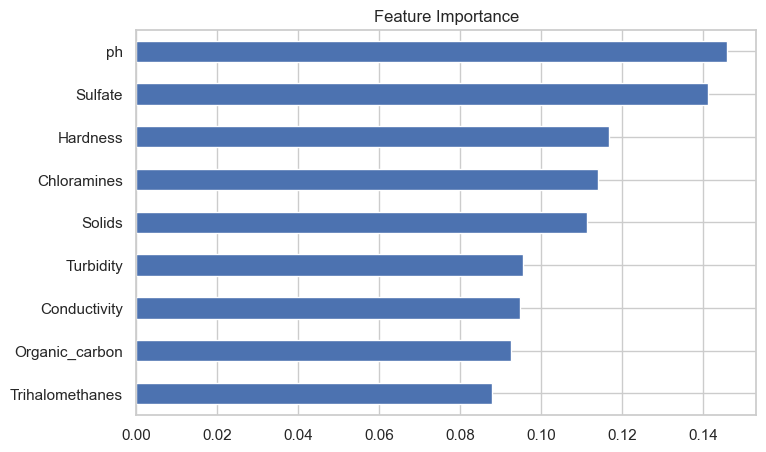

In [442]:
importance = pd.Series(
    rf.feature_importances_,
    index=df.drop("Potability",axis=1).columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Feature Importance")
plt.show()

In [443]:
results.sort_values("Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.73625,0.745455,0.7175,0.731210
3,KNN,0.65125,0.647922,0.6625,0.655130
4,SVM,0.64750,0.646766,0.6500,0.648379
1,Decision Tree,0.61250,0.609756,0.6250,0.617284
0,Logistic Regression,0.51500,0.515000,0.5150,0.515000


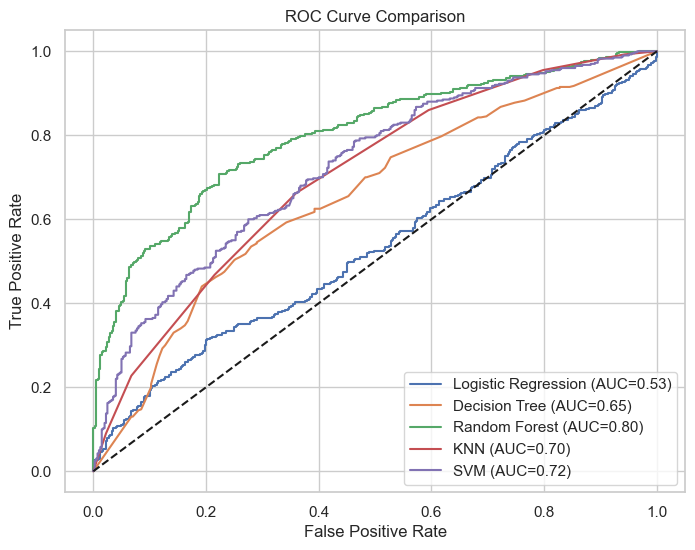

In [444]:
models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "KNN": knn,
    "SVM": svm
}

plt.figure(figsize=(8,6))

for name, model in models.items():
    probs = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.savefig("images/missing_values.png", dpi=300, bbox_inches="tight")
plt.show()

In [445]:
import joblib

joblib.dump(rf, "water_potability_model.pkl")

['water_potability_model.pkl']

In [446]:
results.sort_values("Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.73625,0.745455,0.7175,0.731210
3,KNN,0.65125,0.647922,0.6625,0.655130
4,SVM,0.64750,0.646766,0.6500,0.648379
1,Decision Tree,0.61250,0.609756,0.6250,0.617284
0,Logistic Regression,0.51500,0.515000,0.5150,0.515000
